# 1D Burgers Equation DEMO code

This notebook demonstrates solving 1D Burgers Equation (spatial xy version) using PINNs.

In [1]:
import deepflow as df
print("Deepflow is runned on:", df.device) # to change to cpu use df.device = 'cpu'
df.manual_seed(69) # for reproducibility

Deepflow is runned on: cuda


## 1. Define Geometry Domain
Set up the computational domain

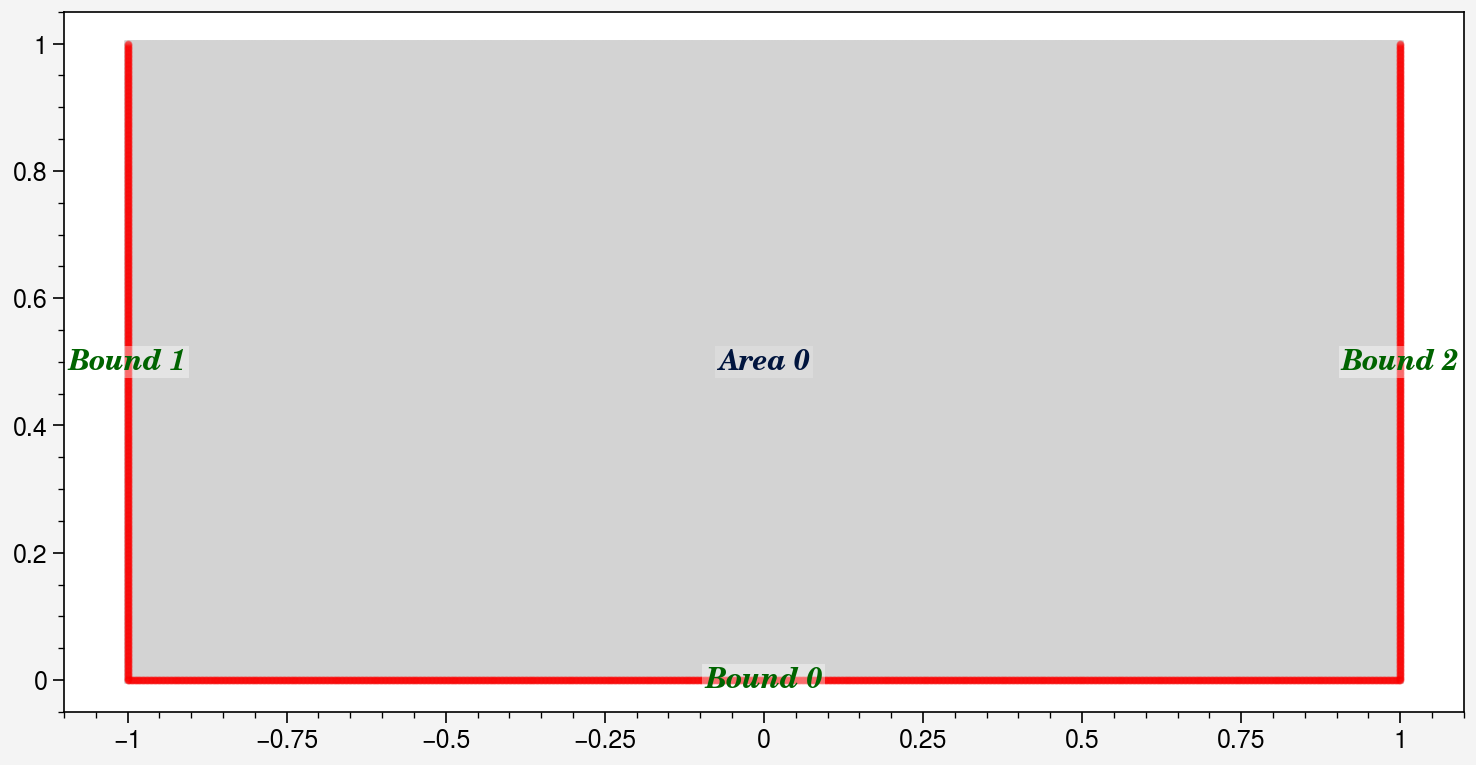

In [2]:
area = df.geometry.rectangle([-1, 1], [0, 1])
line_ic = df.geometry.line_horizontal(y=0, range_x=[-1,1])
line_bc1 = df.geometry.line_vertical(x=-1, range_y=[0,1])
line_bc2 = df.geometry.line_vertical(x=1, range_y=[0,1])
domain = df.domain(area.area_list, line_ic, line_bc1, line_bc2)
domain.show_setup()

## 2. Define Physics
Define the Burgers eq (spatial version) apply boundary conditions.

In [3]:
# Define PDE
from torch import sin, pi
domain.area_list[0].define_pde(df.pde.BurgersEquation1D(nu=0.01/pi))
domain.bound_list[0].define_bc({'u':['x', lambda x: -sin(pi * x)]})
domain.bound_list[1].define_bc({'u': 0})
domain.bound_list[2].define_bc({'u': 0})

### 2. Generate Training Data

Sample initial points for training. After sampling, Deepflow will automatically generate training datasets based on the defined physics.

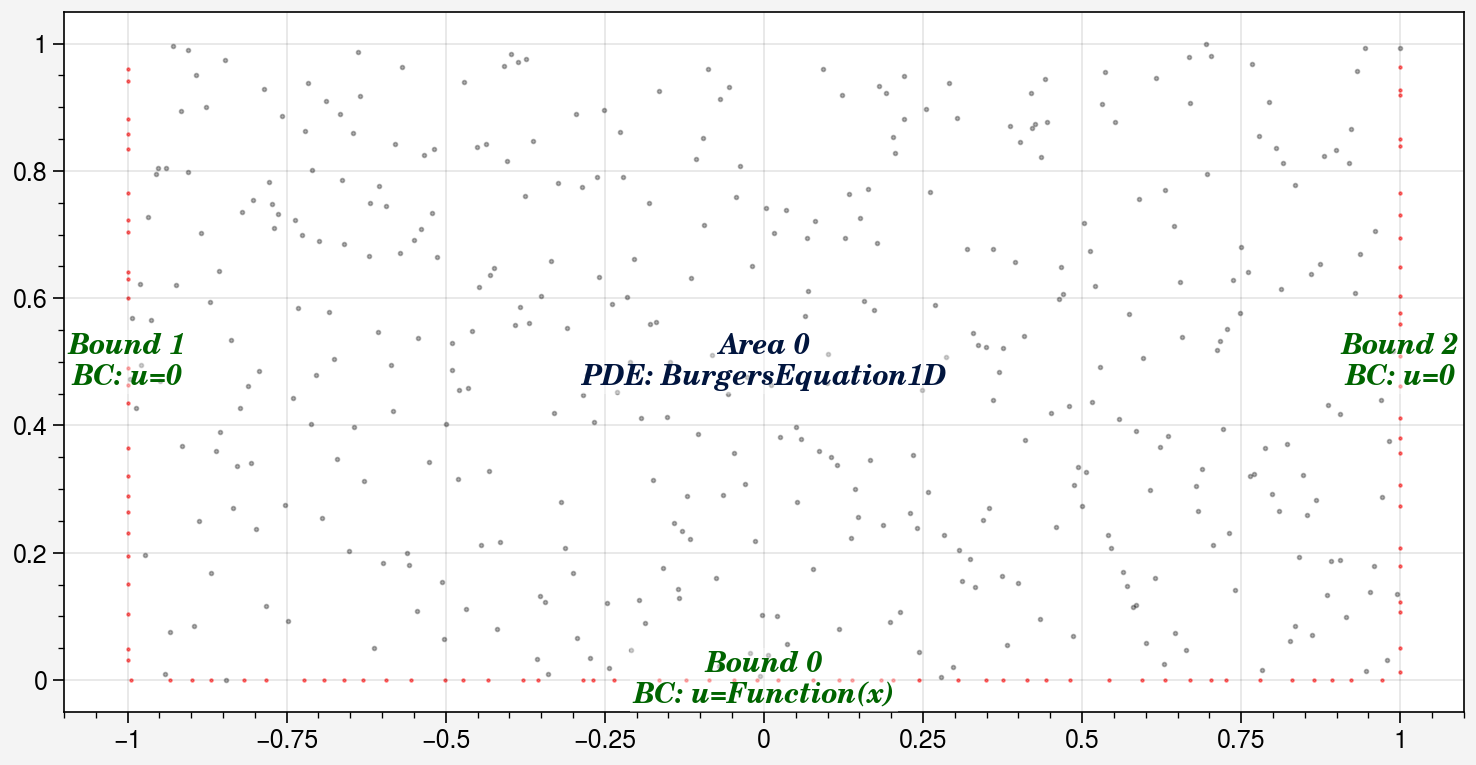

In [4]:
# Sample points: [Left, Bottom, Right, Top], [Interior]
domain.sampling_lhs([50, 25, 25], [400])
domain.show_coordinates(display_physics=True)

### 3. Train the Model

Define the resampling scheme during training. [R3](https://arxiv.org/abs/2207.02338) scheme is recommended.

In [5]:
def do_in_adam(epoch, model):
    if epoch > 0:
        domain.sampling_R3([50, 25, 25], [200])
        if epoch % 200 == 0:
            print(domain)
            domain.show_coordinates(display_resampling=True)

        
def do_in_lbfgs(epoch, model):
    if epoch > 0:
        domain.sampling_R3([50, 25, 25], [200])
        if epoch % 50 == 0:
            print(domain)
            domain.show_coordinates(display_resampling=True)

Train the model using Adam optimizer followed by L-BFGS optimizer.

Epoch: 1, total_loss: 0.86465, bc_loss: 0.86435, pde_loss: 0.00031
Epoch: 200, total_loss: 0.42677, bc_loss: 0.40420, pde_loss: 0.02257
number of bound : ['0: 223', '1: 76', '2: 84']
number of area : ['0: 457']


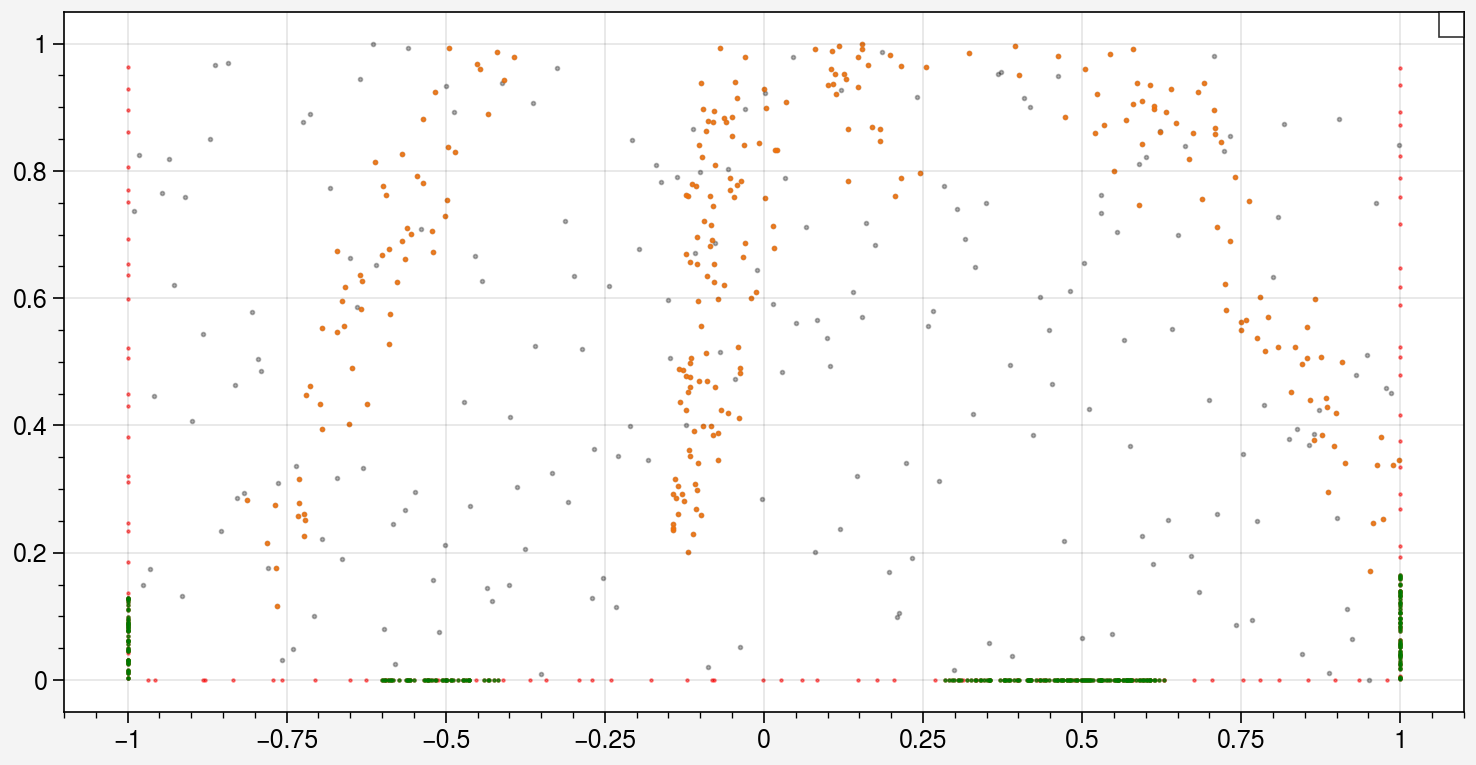

Epoch: 400, total_loss: 0.35082, bc_loss: 0.29668, pde_loss: 0.05415
number of bound : ['0: 228', '1: 43', '2: 75']
number of area : ['0: 403']


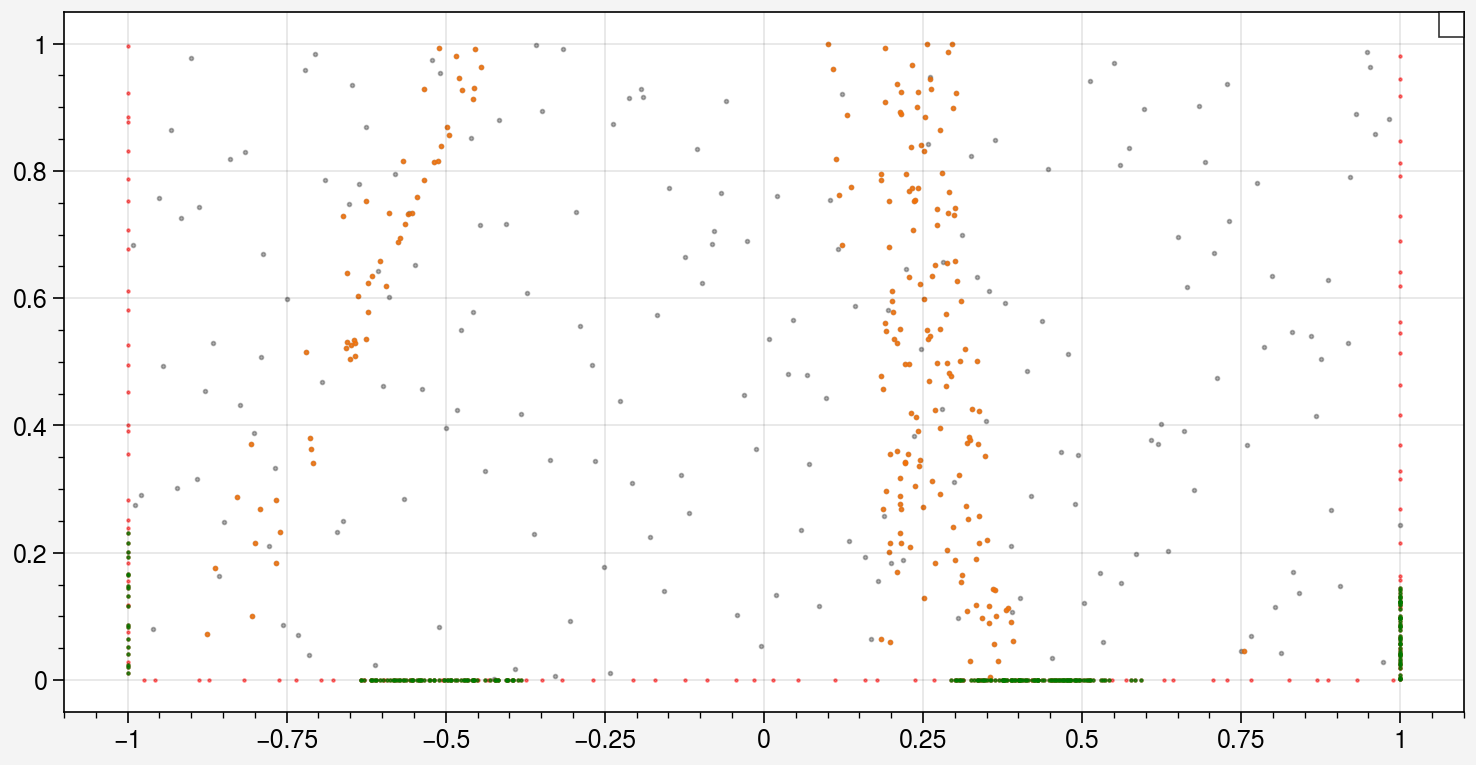

Epoch: 600, total_loss: 0.32517, bc_loss: 0.26367, pde_loss: 0.06150
number of bound : ['0: 247', '1: 55', '2: 99']
number of area : ['0: 410']


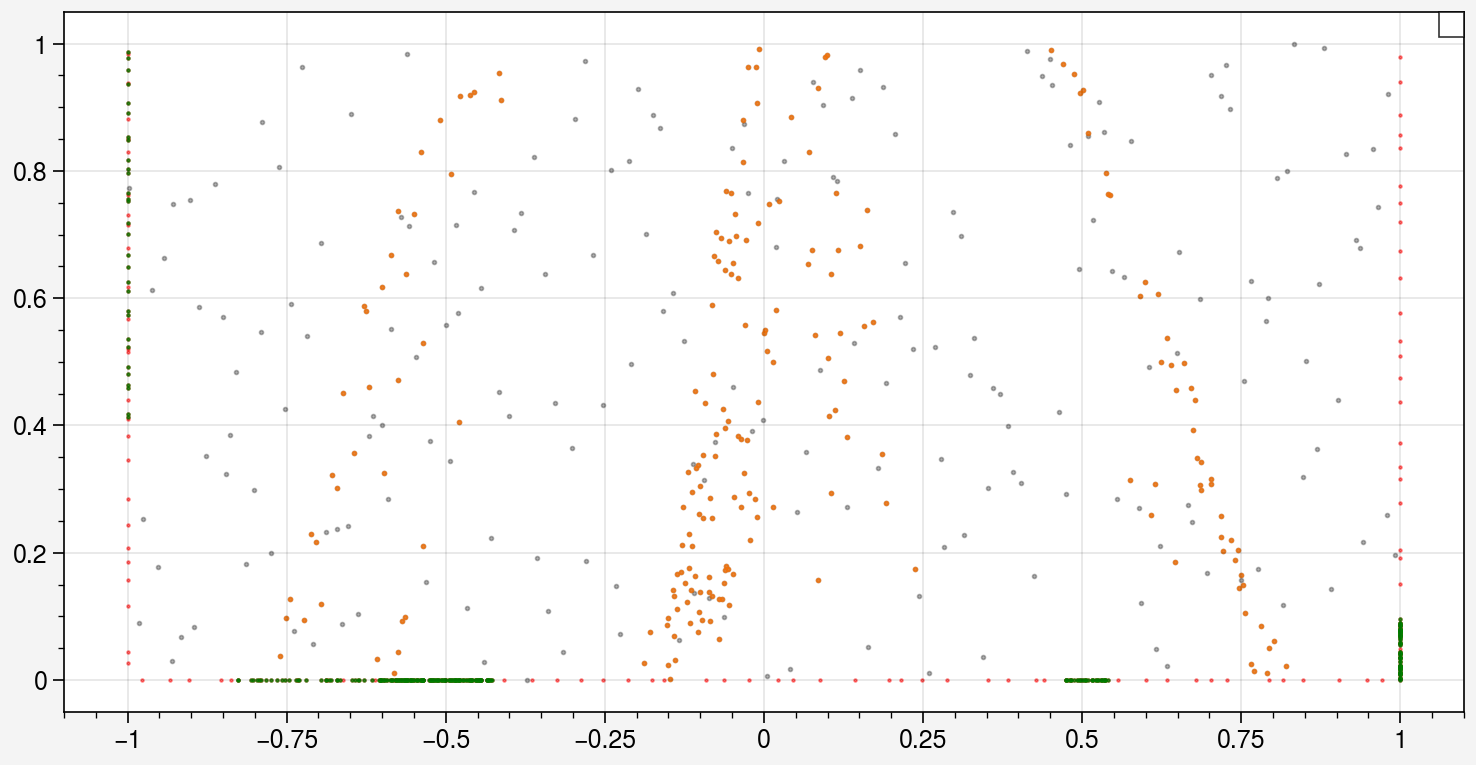

Epoch: 800, total_loss: 0.32392, bc_loss: 0.25875, pde_loss: 0.06516
number of bound : ['0: 200', '1: 48', '2: 73']
number of area : ['0: 453']


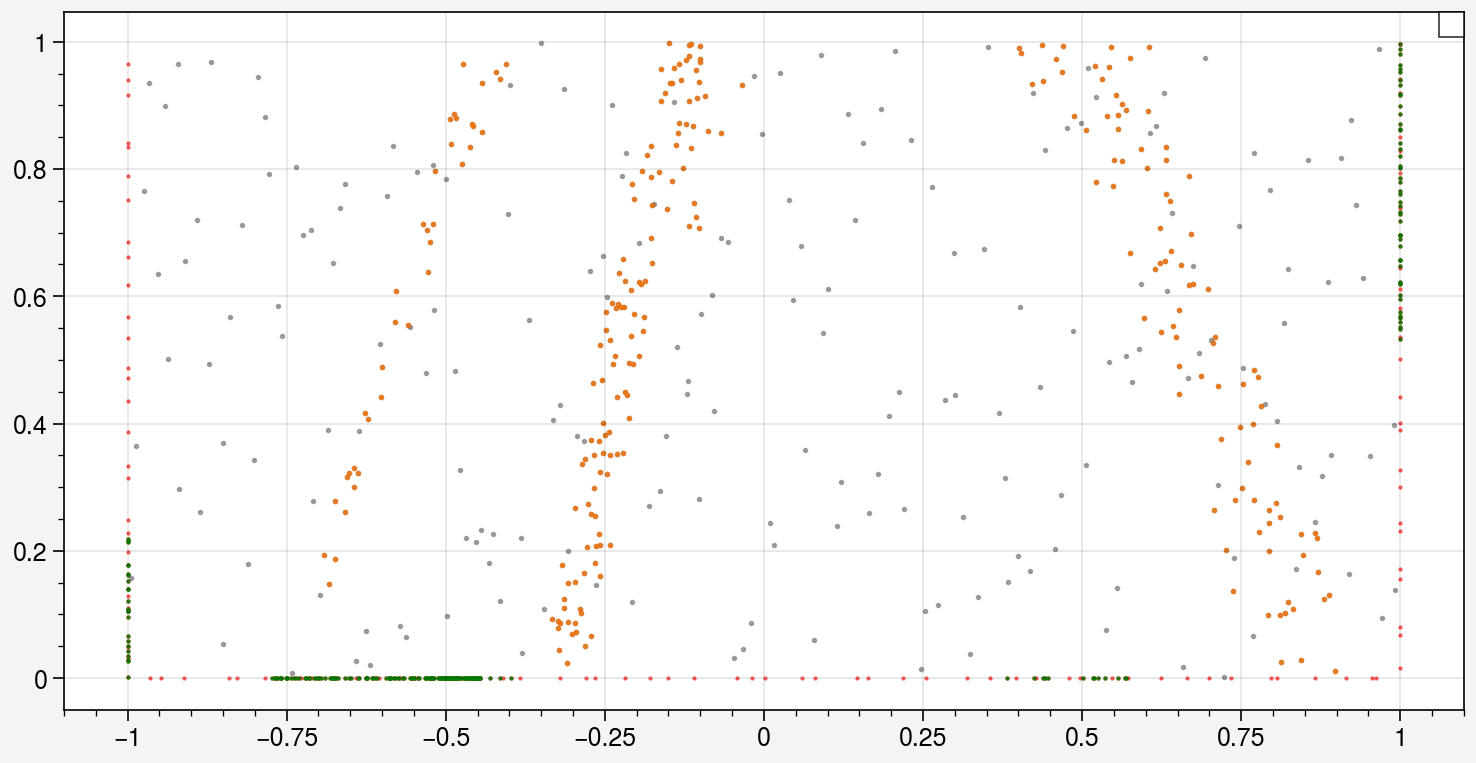

Epoch: 1000, total_loss: 0.24707, bc_loss: 0.19502, pde_loss: 0.05205
number of bound : ['0: 259', '1: 112', '2: 136']
number of area : ['0: 427']


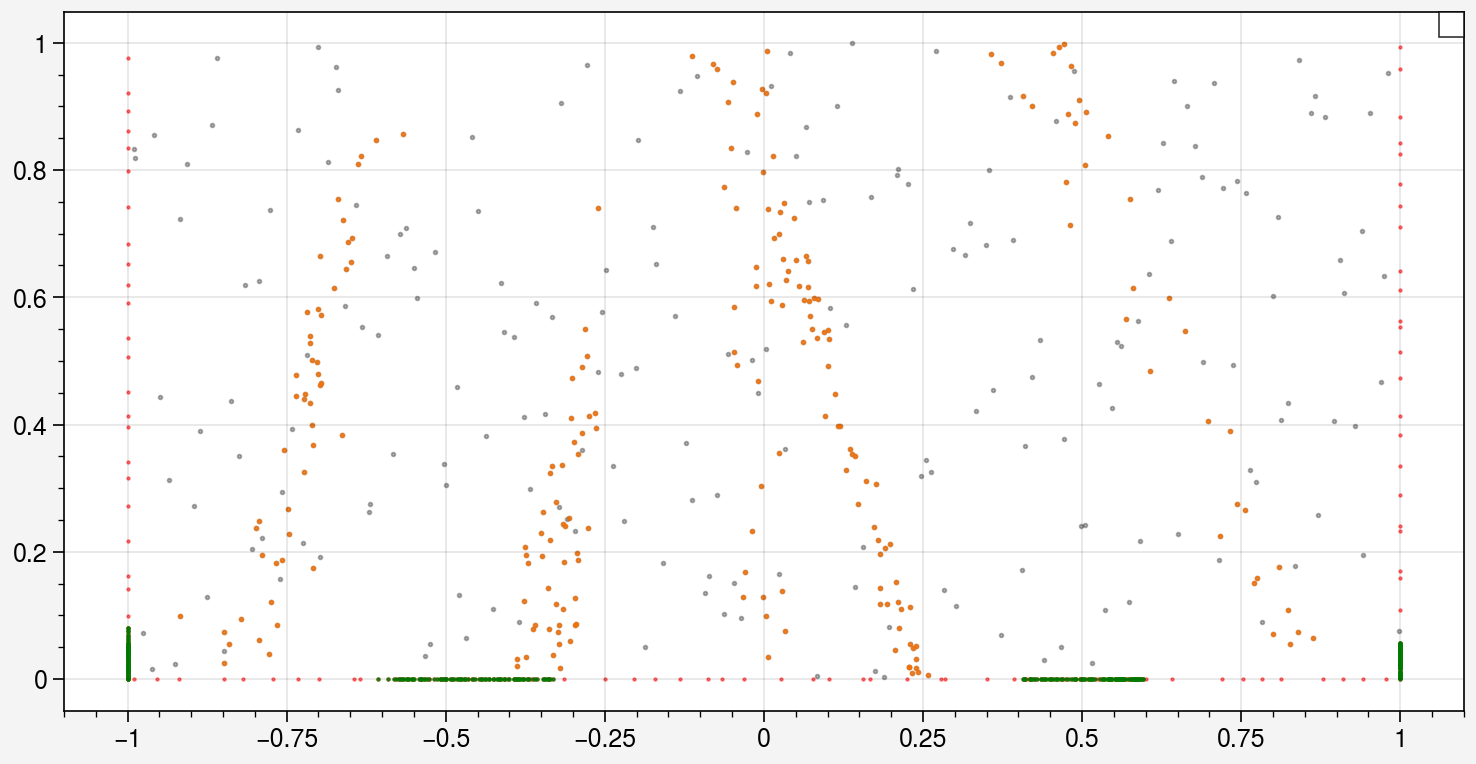

Epoch: 1000, total_loss: 0.24707, bc_loss: 0.19502, pde_loss: 0.05205


In [6]:
model0 = df.QCPINN(input_vars=['x','y'], output_vars=['u'], hidden_layer_pre=[50], hidden_layer_post=[50], nqubits=5, q_layer_iterations=1)

model1, model1_best = model0.train_adam(
    calc_loss = df.calc_loss_simple(domain),
    learning_rate=0.01,
    epochs=1000,
    do_between_epochs=do_in_adam)

Epoch: 1001, total_loss: 0.15677, bc_loss: 0.08947, pde_loss: 0.06730
Epoch: 1051, total_loss: 0.03130, bc_loss: 0.01586, pde_loss: 0.01544
number of bound : ['0: 106', '1: 53', '2: 53']
number of area : ['0: 331']


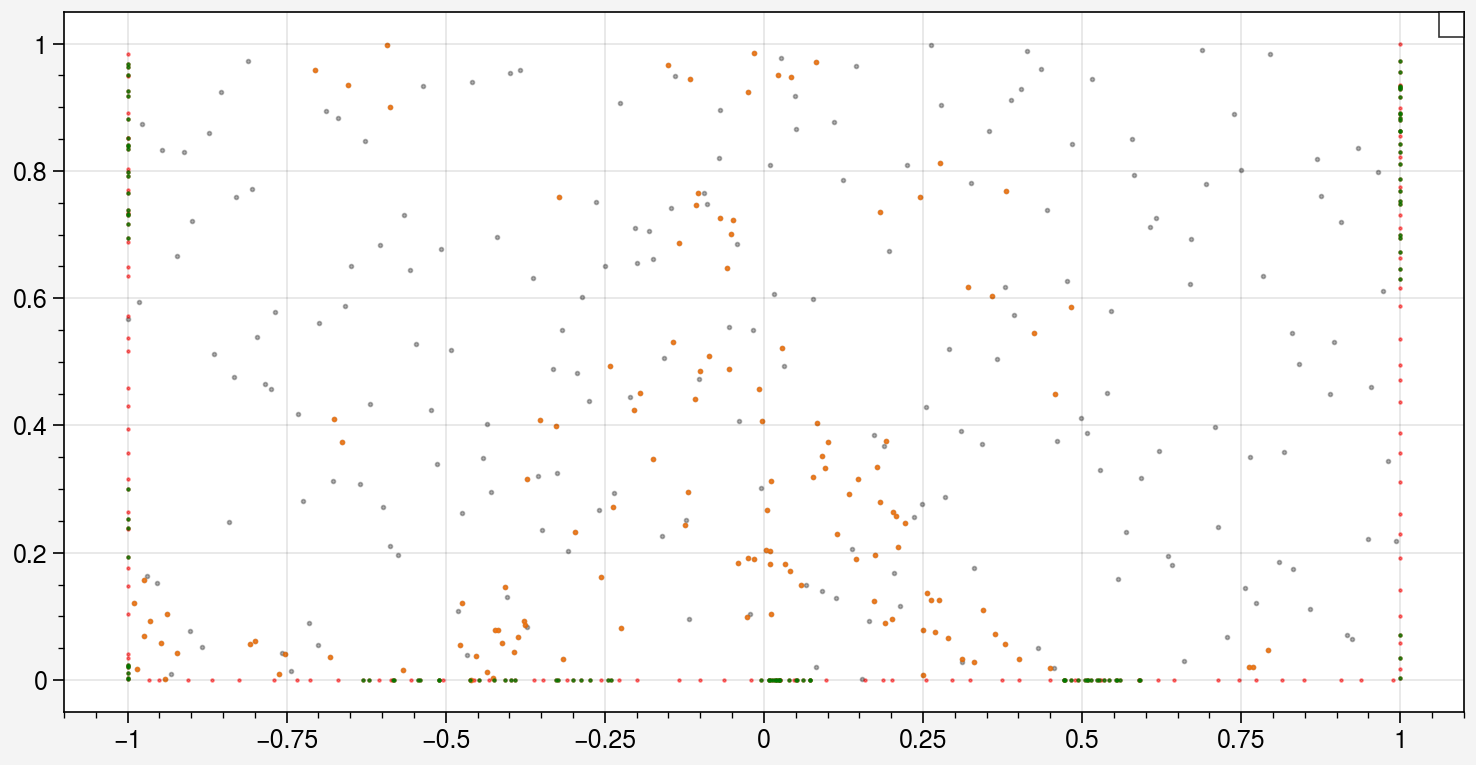

Epoch: 1101, total_loss: 0.02429, bc_loss: 0.00988, pde_loss: 0.01440
number of bound : ['0: 120', '1: 52', '2: 44']
number of area : ['0: 305']


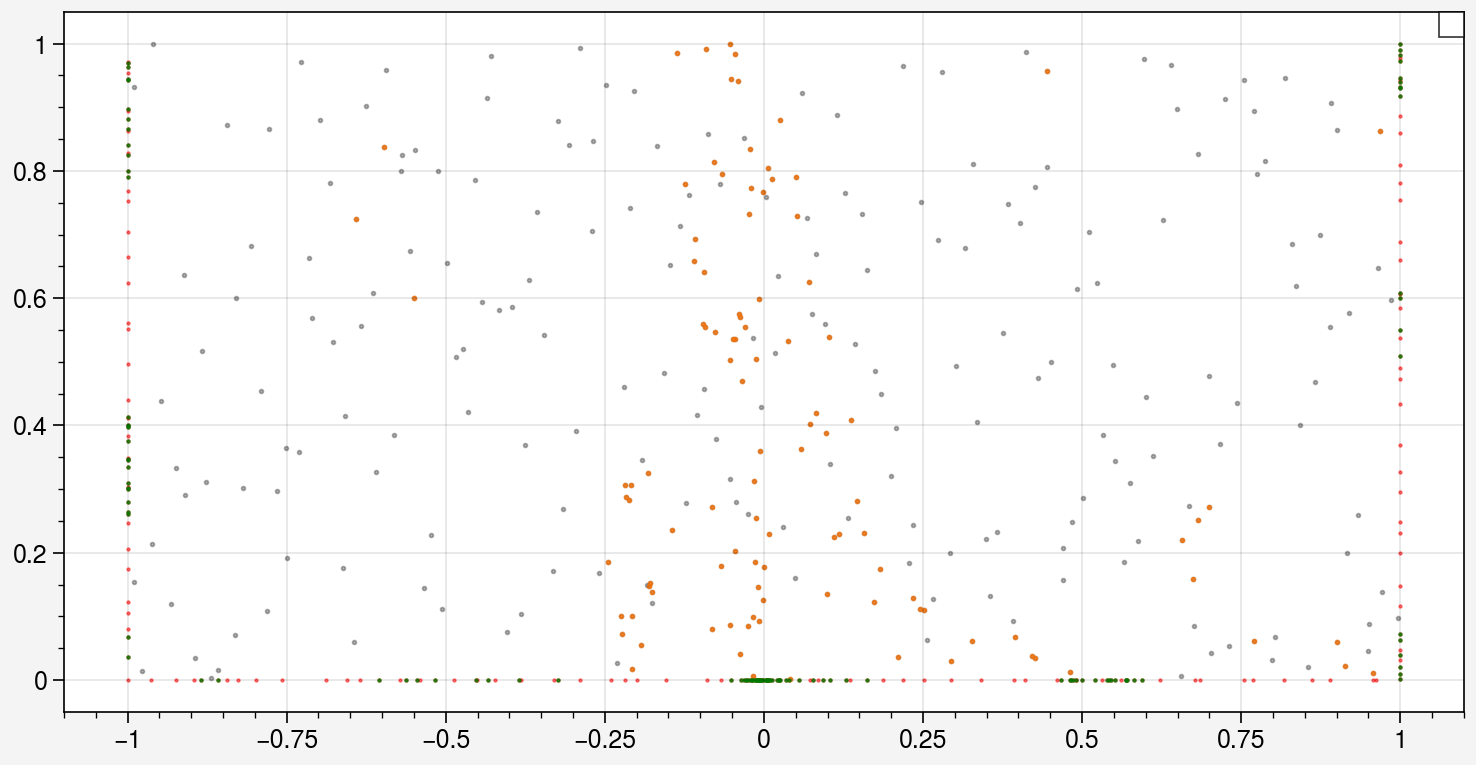

Epoch: 1150, total_loss: 0.02963, bc_loss: 0.01337, pde_loss: 0.01625


In [ ]:
model2 = model1.train_lbfgs(
    calc_loss = df.calc_loss_simple(domain), 
    epochs=300, 
    do_between_epochs=do_in_lbfgs,
)

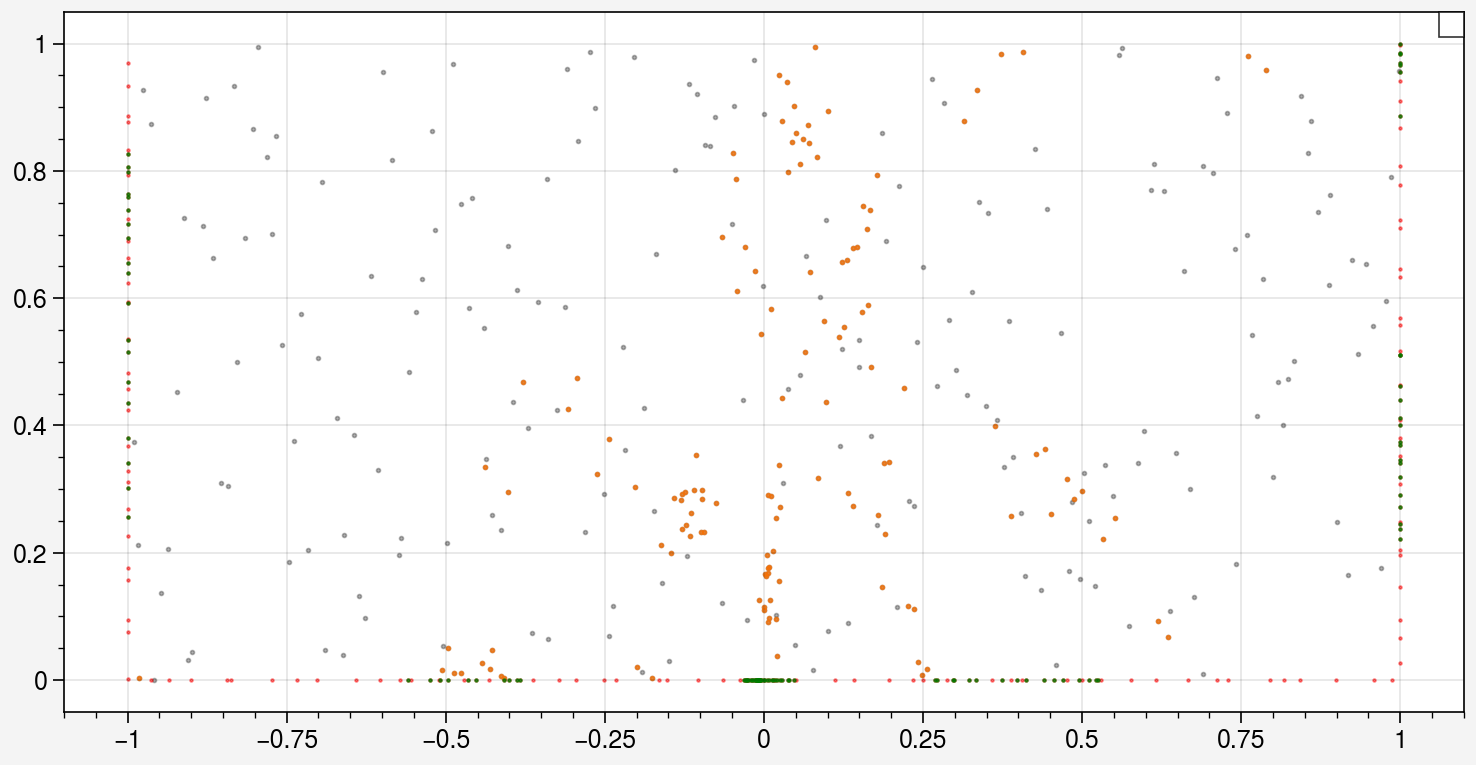

In [9]:
domain.show_coordinates(display_physics=False, display_resampling=True)

## 4. Visualization

In [ ]:
# Evaluate the best model
prediction = domain.area_list[0].evaluate(model2)
# Sampling uniform points
prediction.sampling_area([500, 250])

OutOfMemoryError: CUDA out of memory. Tried to allocate 62.00 MiB. GPU 0 has a total capacity of 6.00 GiB of which 0 bytes is free. Of the allocated memory 16.23 GiB is allocated by PyTorch, and 191.63 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

### 4.1 Visualize PDE area

In [ ]:
import numpy as np
prediction["pde_residual"] = np.clip(prediction["pde_residual"], 0, 1) # for better visualization

C:\Users\thamm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\events.py:82: UltraPlotWarning: Tick label sharing not implemented for <class 'ultraplot.axes.three.ThreeAxes'> subplots.
  func(*args, **kwargs)


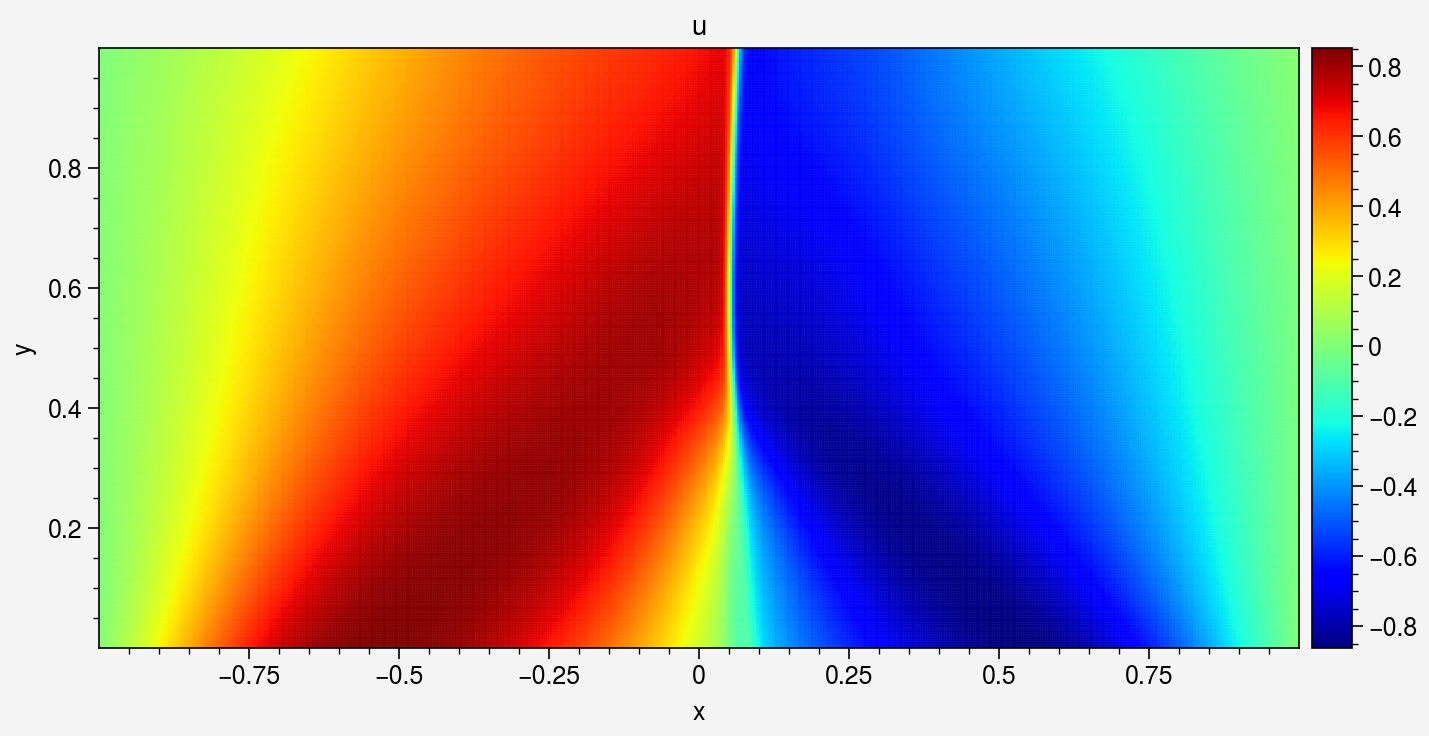

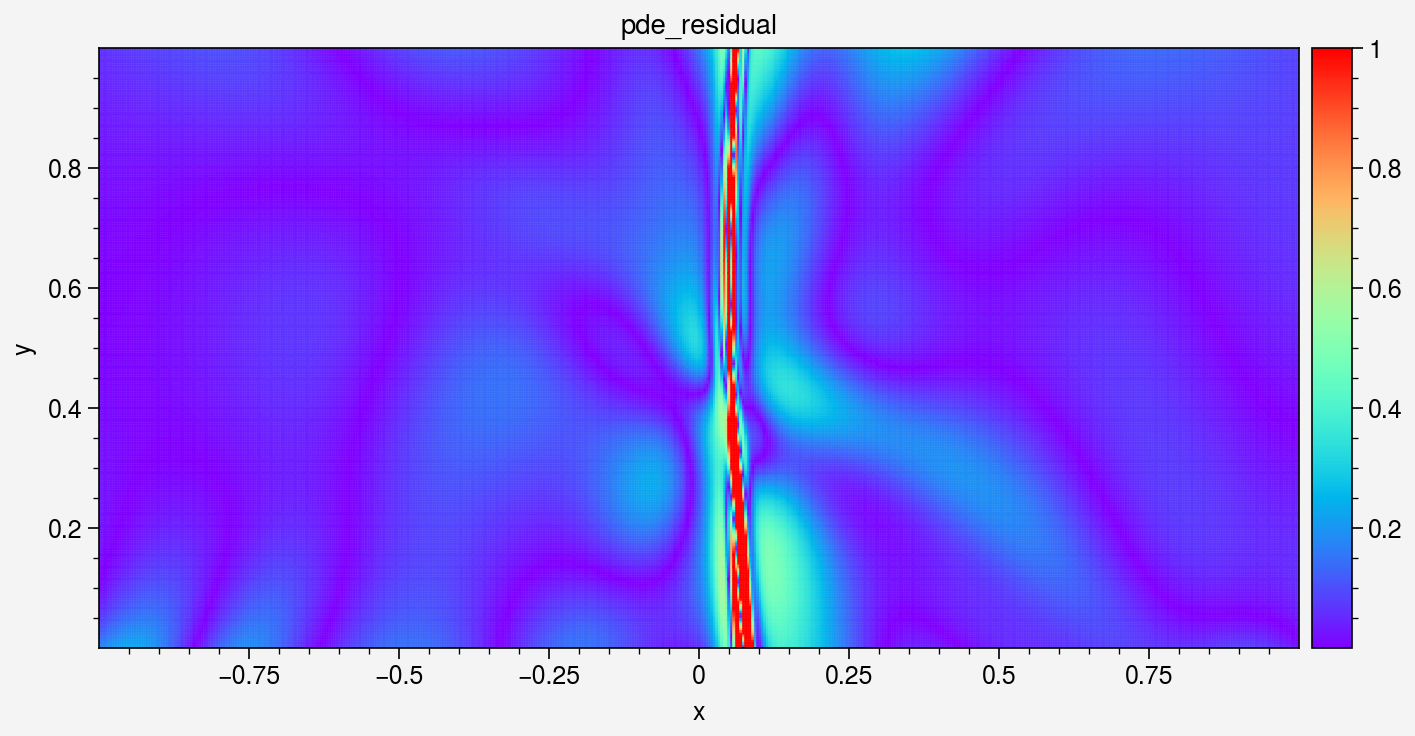

C:\Users\thamm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UltraPlotWarning: Tick label sharing not implemented for <class 'ultraplot.axes.three.ThreeAxes'> subplots.
  fig.canvas.print_figure(bytes_io, **kw)


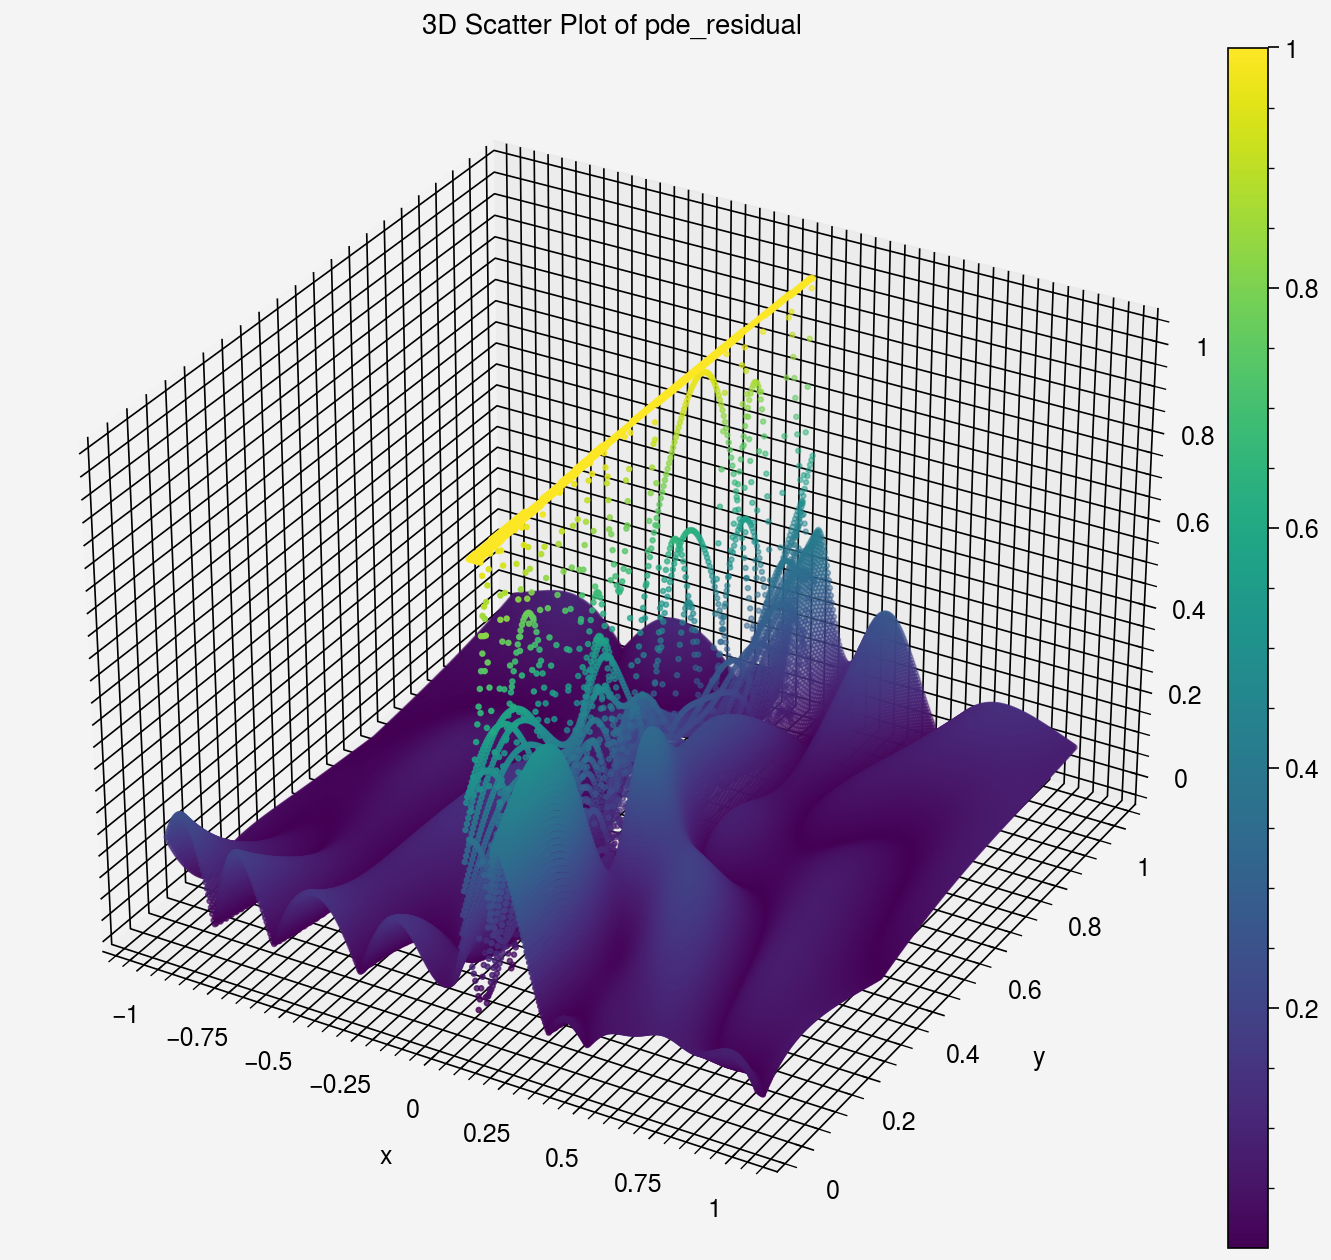

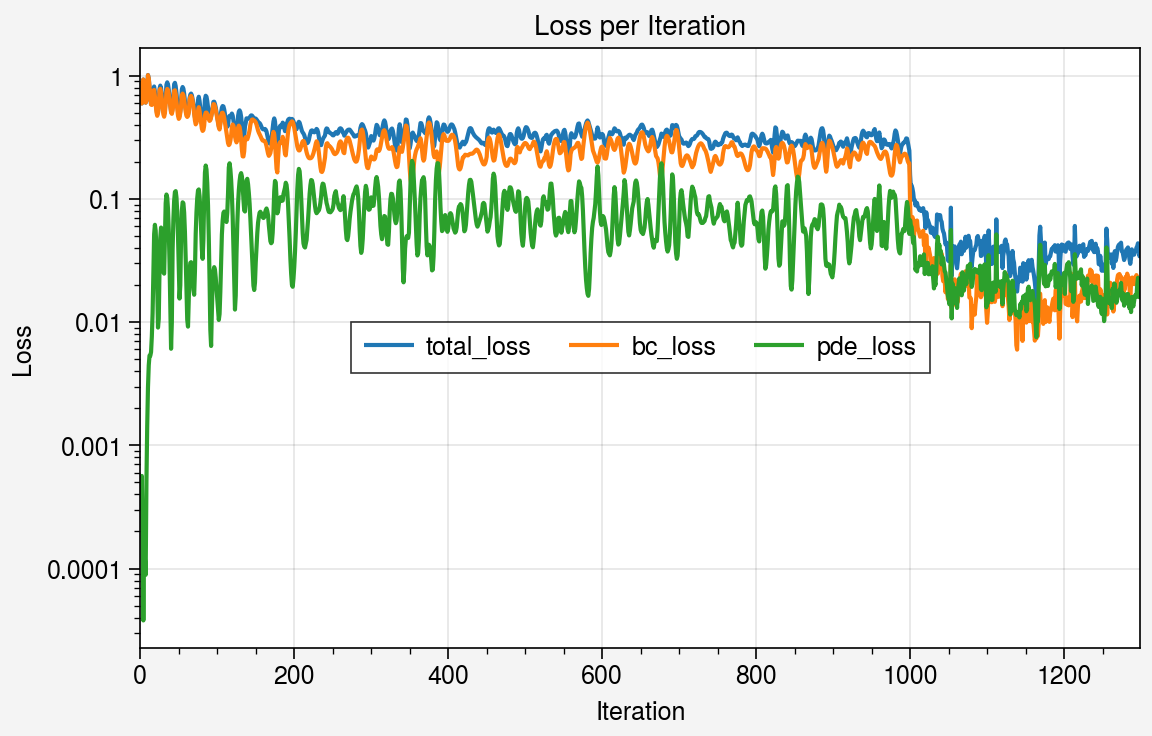

In [ ]:
# Plot Velocity Field
prediction.plot_color('u', cmap = 'jet', s=0.3).savefig('u_field.png')
_ = prediction.plot_color('pde_residual', cmap = 'rainbow', s=0.3)
_ = prediction.plot('pde_residual')
_ = prediction.plot_loss_curve(log_scale=True)

### 4.2 Visualize u at y = 0.75

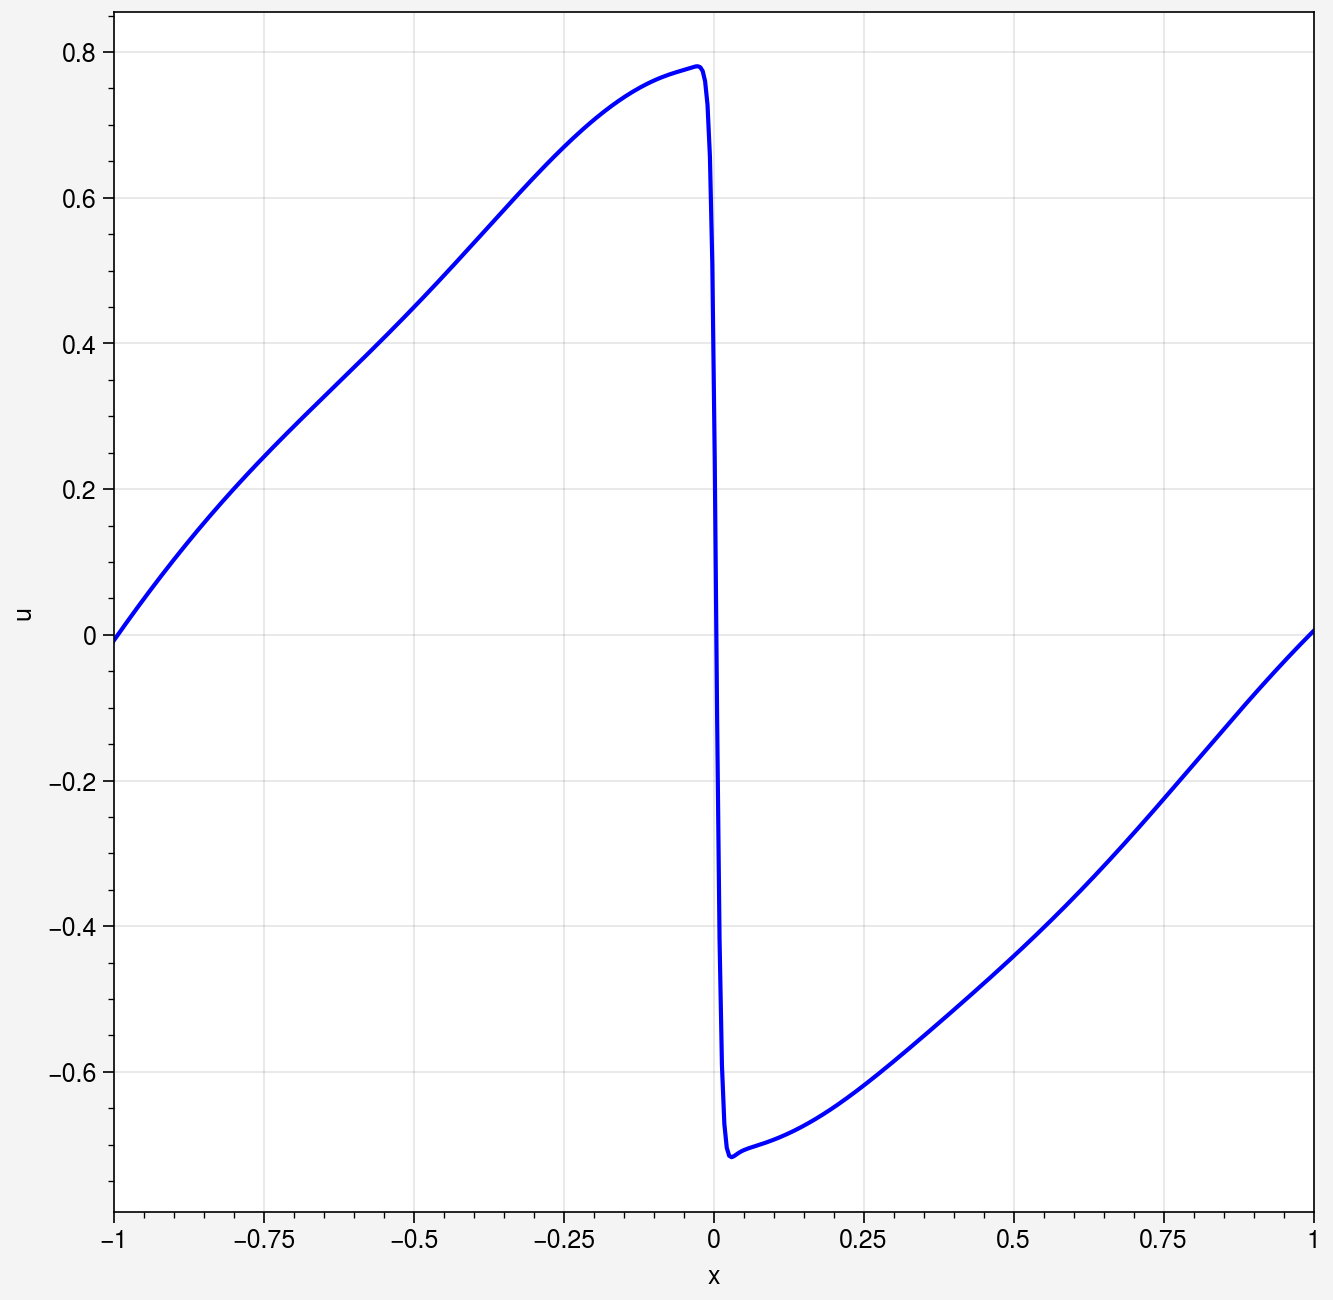

In [13]:
line = df.geometry.line_horizontal(y=0.75, range_x=[-1, 1])
prediction = line.evaluate(model2)
prediction.sampling_line(500)
_ = prediction.plot(y_axis = 'u')